# Roundoff accumulation with dimension

This notebook studies how finite-precision effects accumulate when a single
tensor-product polynomial $\Psi_{(p,\ldots,p)}$ is emulated in increasing
dimension. It compares ReLU, tanh, and RePU-2 multiplication in both the
functional and materialized-feedforward implementations.

The primary roundoff proxy is the discrepancy between float32 and float64
evaluations of the same construction at identical float32-representable sample
points. The tanh step is fixed explicitly, so changing dtype does not change
the mathematical finite-difference construction. This is an empirical
precision-sensitivity experiment, not a rigorous forward-error bound.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from neural_polynomial_emulation import (
    MultivariateBasisEmulator,
    exact_multivariate_basis,
    to_feedforward,
)

FAMILY = "legendre"
DEGREE = 1
DIMENSIONS = (1, 2, 3, 4, 6, 8, 12, 16, 20, 24)
N_SAMPLES = 4096
SEED = 2026
RELU_DEPTH = 12
TANH_STEP = 0.1
TANH_TOLERANCE = 1e-6
PRODUCTS = ("relu", "tanh", "repu2")
IMPLEMENTATIONS = ("functional", "feedforward")

BACKGROUND = "#071018"
INK = "#dbe9f4"
PRODUCT_COLORS = {
    "relu": "#38b8dc",
    "tanh": "#c7df55",
    "repu2": "#ee9732",
}
PRODUCT_LABELS = {"relu": "ReLU", "tanh": "tanh", "repu2": "RePU-2"}
IMPLEMENTATION_STYLES = {"functional": "-", "feedforward": "--"}


For Legendre polynomials, samples follow the product of the uniform
probability measure $dx/2$. For Chebyshev polynomials, setting
`FAMILY = "chebyshev"` samples $x=\cos(\pi U)$, which has probability
measure $dx/(\pi\sqrt{1-x^2})$. Thus the reported RMS values estimate the
appropriate probability-$L^2$ norms.


In [2]:
def sample_points(number, dimension, family, generator):
    unit = torch.rand(
        (number, dimension), generator=generator, dtype=torch.float32
    )
    if family == "legendre":
        return 2.0 * unit - 1.0
    if family == "chebyshev":
        return torch.cos(torch.pi * unit)
    raise ValueError("FAMILY must be 'legendre' or 'chebyshev'")


def probability_l2(values):
    return torch.mean(values.square()).sqrt().item()


def build_model(multi_index, product, implementation, dtype):
    model = MultivariateBasisEmulator(
        multi_index,
        family=FAMILY,
        product=product,
        num_layers=RELU_DEPTH,
        tanh_step=TANH_STEP,
        tanh_tolerance=TANH_TOLERANCE,
    )
    if implementation == "feedforward":
        model = to_feedforward(model, dtype=dtype)
    else:
        model = model.to(dtype=dtype)
    return model.eval()


def style_axis(axis):
    axis.set_facecolor(BACKGROUND)
    axis.tick_params(colors=INK)
    axis.xaxis.label.set_color(INK)
    axis.yaxis.label.set_color(INK)
    axis.title.set_color(INK)
    axis.grid(True, color="#527487", alpha=0.22, linewidth=0.6)
    for spine in axis.spines.values():
        spine.set_color("#527487")


In [3]:
generator = torch.Generator().manual_seed(SEED)
points32 = sample_points(N_SAMPLES, max(DIMENSIONS), FAMILY, generator)
points64 = points32.to(torch.float64)
rows = []

with torch.no_grad():
    for dimension in DIMENSIONS:
        multi_index = np.full((1, dimension), DEGREE, dtype=np.int64)
        x32 = points32[:, :dimension]
        x64 = points64[:, :dimension]
        exact = exact_multivariate_basis(x64, multi_index, family=FAMILY)[:, 0]

        for product in PRODUCTS:
            for implementation in IMPLEMENTATIONS:
                model64 = build_model(
                    multi_index, product, implementation, torch.float64
                )
                model32 = build_model(
                    multi_index, product, implementation, torch.float32
                )
                output64 = model64(x64)[:, 0]
                output32 = model32(x32)[:, 0].to(torch.float64)
                discrepancy = output32 - output64
                reference_l2 = probability_l2(output64)
                roundoff_l2 = probability_l2(discrepancy)
                rows.append(
                    {
                        "dimension": dimension,
                        "cross_multiplications": max(dimension - 1, 0),
                        "product": product,
                        "implementation": implementation,
                        "roundoff_l2": roundoff_l2,
                        "relative_roundoff_l2": roundoff_l2
                        / max(reference_l2, np.finfo(np.float64).tiny),
                        "roundoff_linf": torch.max(
                            torch.abs(discrepancy)
                        ).item(),
                        "float64_error_l2": probability_l2(output64 - exact),
                        "float32_error_l2": probability_l2(output32 - exact),
                    }
                )

results = pd.DataFrame(rows)
results.head(12)


,dimension,cross_multiplications,product,implementation,roundoff_l2,relative_roundoff_l2,roundoff_linf,float64_error_l2,float32_error_l2
0,1,0,relu,functional,3.063037e-08,3.084408e-08,8.931821e-08,0.000000e+00,3.063037e-08
1,1,0,relu,feedforward,3.063037e-08,3.084408e-08,8.931821e-08,0.000000e+00,3.063037e-08
2,1,0,tanh,functional,3.063037e-08,3.084408e-08,8.931821e-08,0.000000e+00,3.063037e-08
3,1,0,tanh,feedforward,3.063037e-08,3.084408e-08,8.931821e-08,0.000000e+00,3.063037e-08
4,1,0,repu2,functional,3.063037e-08,3.084408e-08,8.931821e-08,0.000000e+00,3.063037e-08
5,1,0,repu2,feedforward,3.063037e-08,3.084408e-08,8.931821e-08,0.000000e+00,3.063037e-08
6,2,1,relu,functional,3.505661e-07,3.556490e-07,2.504094e-06,1.652629e-07,3.982364e-07
7,2,1,relu,feedforward,3.244066e-07,3.291102e-07,2.907967e-06,1.652629e-07,3.760782e-07
8,2,1,tanh,functional,1.880943e-05,1.908220e-05,6.044091e-05,2.889441e-06,1.902799e-05
9,2,1,tanh,feedforward,1.884903e-05,1.912237e-05,6.056012e-05,2.889441e-06,1.906922e-05


## Dimension-dependent precision loss

Solid lines are the existing functional constructions; dashed lines are the
materialized feedforward translations. The first three panels isolate the
float32--float64 discrepancy. The final panel shows total float32 error against
the exact probability-normalized tensor-product polynomial, which also includes
the approximation error intrinsic to ReLU and tanh multiplication.


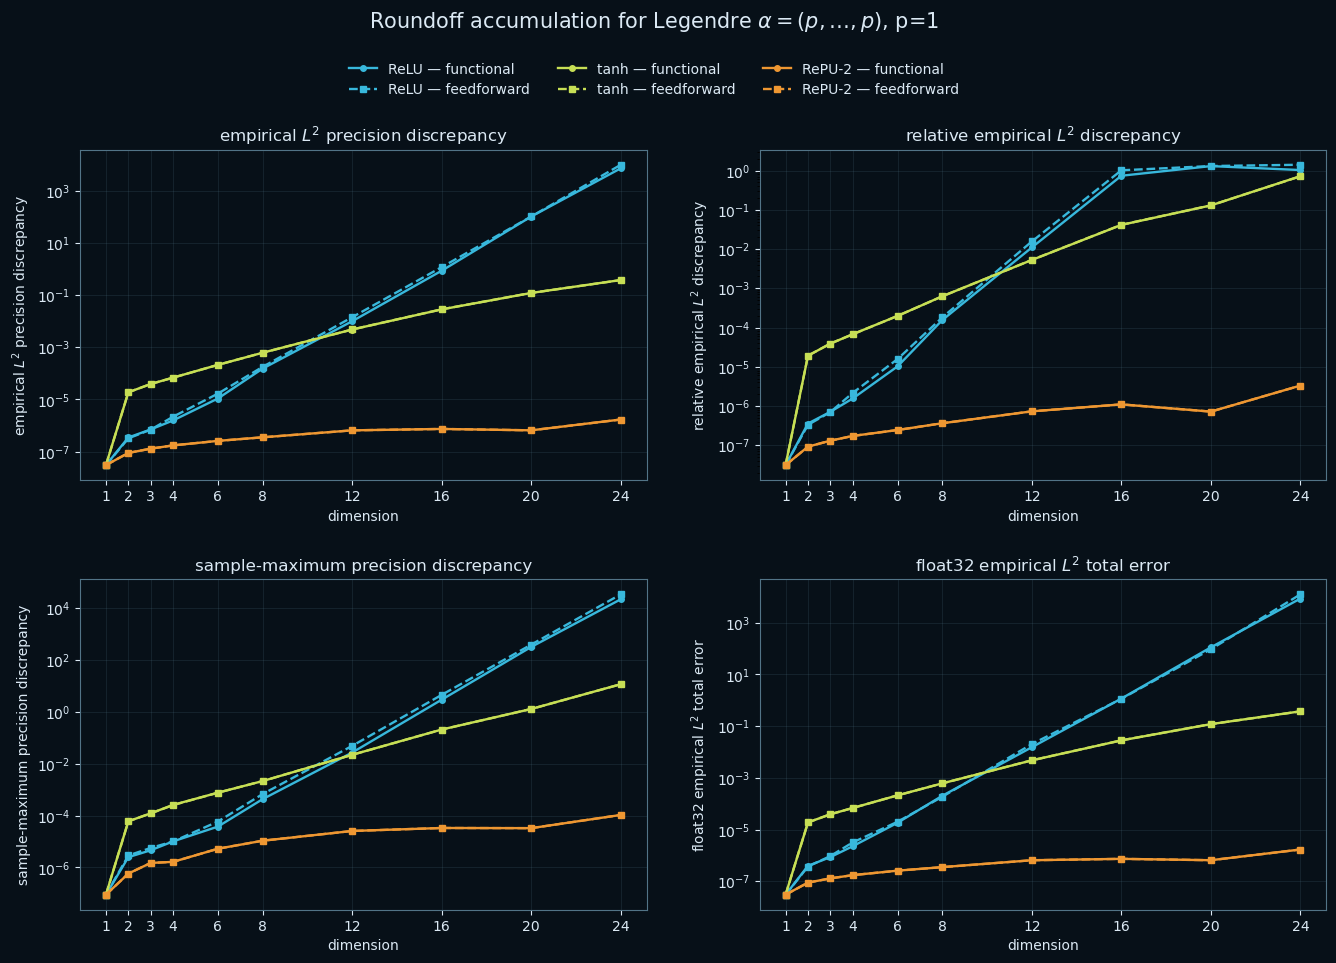

In [4]:
metrics = (
    ("roundoff_l2", r"empirical $L^2$ precision discrepancy"),
    ("relative_roundoff_l2", r"relative empirical $L^2$ discrepancy"),
    ("roundoff_linf", r"sample-maximum precision discrepancy"),
    ("float32_error_l2", r"float32 empirical $L^2$ total error"),
)
floor = np.finfo(np.float64).tiny
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(BACKGROUND)
handles = []
labels = []

for axis, (metric, title) in zip(axes.ravel(), metrics, strict=True):
    for product in PRODUCTS:
        for implementation in IMPLEMENTATIONS:
            selected = results[
                (results["product"] == product)
                & (results["implementation"] == implementation)
            ]
            (line,) = axis.plot(
                selected["dimension"],
                np.maximum(selected[metric], floor),
                color=PRODUCT_COLORS[product],
                linestyle=IMPLEMENTATION_STYLES[implementation],
                marker="o" if implementation == "functional" else "s",
                markersize=4,
                linewidth=1.7,
                label=f"{PRODUCT_LABELS[product]} — {implementation}",
            )
            if metric == metrics[0][0]:
                handles.append(line)
                labels.append(line.get_label())
    axis.set_yscale("log")
    axis.set_xticks(DIMENSIONS)
    axis.set_xlabel("dimension")
    axis.set_ylabel(title)
    axis.set_title(title)
    style_axis(axis)

fig.suptitle(
    rf"Roundoff accumulation for {FAMILY.title()} $\alpha=(p,\ldots,p)$, p={DEGREE}",
    color=INK,
    fontsize=15,
)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=3,
    frameon=False,
    labelcolor=INK,
)
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.08, top=0.84, hspace=0.30)
plt.show()


## Largest-dimension summary


In [5]:
summary = results[results["dimension"] == max(DIMENSIONS)].copy()
summary[
    [
        "product",
        "implementation",
        "roundoff_l2",
        "relative_roundoff_l2",
        "roundoff_linf",
        "float64_error_l2",
        "float32_error_l2",
    ]
].reset_index(drop=True)


,product,implementation,roundoff_l2,relative_roundoff_l2,roundoff_linf,float64_error_l2,float32_error_l2
0,relu,functional,7124.449094,1.038521,21938.948237,6.860195e+03,8594.824401
1,relu,feedforward,9729.078097,1.418223,33987.134840,6.860053e+03,12492.262644
2,tanh,functional,0.375199,0.725182,11.638359,8.270810e-06,0.375200
3,tanh,feedforward,0.373301,0.721514,11.637925,8.270831e-06,0.373302
4,repu2,functional,0.000002,0.000003,0.000106,1.273482e-15,0.000002
5,repu2,feedforward,0.000002,0.000003,0.000106,1.273482e-15,0.000002


RePU-2 is algebraically exact, but its repeated additions, subtractions, and
squarings still accumulate floating-point error. ReLU and tanh additionally
carry construction error, and their intermediate bounds can amplify absolute
roundoff as dimension grows. Differences between solid and dashed curves reveal
the effect of evaluating the same construction with different affine groupings.

At high dimension, tensor-product values are heavy-tailed even though each
basis function has probability-$L^2$ norm one. Increase `N_SAMPLES` before
using the empirical norms for quantitative conclusions.
